# Apresentação dos resultados - CUDA

**Discente: Igor Sousa dos Santos Santana**
<br>
**Docente: Esbel Tomás Valero Orellana**
<br>
**Disciplina: Processamento Paralelo**
<br>

## A proposta

Este trabalho propõe o desenvolvimento e a análise de desempenho de um algoritmo para o cálculo de *Bounding Box* aplicado a conjuntos de dados multidimensionais.
<br>
A implementação é realizada integralmente na linguagem C (CUDA), focando em eficiência, paralelismo baseado em processamento paralelo em placas gráficas (NVIDIA).

### Objetivos Principais:

- **Estrutura de Dados Customizada:** Para gerenciar os dados de entrada, foi implementada uma estrutura chamada Tensor, que encapsula o ponteiro de dados e as informações de dimensionalidade, permitindo uma manipulação robusta de volumes de dados médicos ou científicos.
- **Implementação Sequencial:** Desenvolvimento de uma versão de referência executada em um único processo, garantindo a corretude do cálculo dos limites espaciais da região de interesse.
- **Implementação Paralela com MPI:** Integração da biblioteca MPI, Message Passing Interface, para particionar os dados e distribuir a carga de processamento entre múltiplos processos independentes, visando reduzir o tempo de execução em grandes volumes de dados.
    - Os testes computacionais foram realizados utilizando uma configuração estável de 16 processos paralelos;
    - O ambiente de execução consistiu em uma máquina dedicada de 16 núcleos físicos, permitindo o mapeamento nativo de um processo por núcleo da CPU;
    - Para a análise dos resultados deste trabalho, foram consolidados os dados de tempo e desempenho obtidos estritamente sob essa arquitetura de 16 processos.

### Estudo de Desempenho e Estratégias de Otimização com CUDA:

O foco central é a comparação entre diferentes estratégias de mapeamento de threads, organização da malha de computação (grid) e gerenciamento de memória fornecidos pela arquitetura CUDA. O objetivo é identificar qual abordagem de particionamento do volume e consolidação de resultados melhor se adapta à carga de trabalho do algoritmo de Bounding Box sobre a estrutura de Tensor 3D. Estão sendo avaliadas as seguintes abordagens:
- **Sequencial (CPU Host):** Execução isolada e linear no processador principal, CPU, sem paralelismo, servindo como linha de base para as métricas de aceleração;
- Mapeamento Estático de Threads (Mapeamento Direto): Divisão uniforme e contígua das dimensões do Tensor em blocos tridimensionais de threads (8×8×8). Cada thread se encarrega de computar um único elemento da matriz na memória global, minimizando a complexidade do código de indexação;
- **Fusão de Kernels (Kernel Fusion):** Amalgamação de múltiplas etapas do pipeline, binarização e extração de índices, em um único disparo de kernel. Essa estratégia visa mitigar o custo de acessos repetitivos à memória global da VRAM e eliminar o overhead de múltiplos lançamentos de funções pela CPU;
- **Redução por Operações Atômicas e Controle de Fluxo:** Utilização de instruções nativas de hardware (como atomicMin e atomicMax) integradas a kernels dedicados de controle para consolidar as coordenadas locais da *Bounding Box* diretamente na GPU. Essa abordagem elimina a necessidade de transferências intermediárias redundantes de dados através do barramento PCIe.

Ao final desta análise, os resultados de tempo de execução, speedup, ocupação da GPU e eficiência na largura de banda da memória serão confrontados para determinar a melhor configuração de execução paralela (geometria de blocos e grades) e a topologia de otimização de memória ideal para a estrutura de Tensor proposta.

## Implementação

Nesse capítulo serão apresentados os códigos fonte em C (CUDA) e Python utilizados para gerar os dados explorados nesse trabalho.
<br>
O código C foi exportado para uma biblioteca dinamica (.so) para uso direto em conjunção com os códigos da linguagem Python.

### C (CUDA)

```c
#include <ctime>
#include <stdio.h>
#include <stdlib.h>
#include <time.h>
#include <cuda_runtime.h>

#ifdef _WIN32
#define EXPORT __declspec(dllexport)
#else
#define EXPORT
#endif

#ifdef __cplusplus
extern "C" {
#endif

EXPORT __device__ void get_indices_with_padding(int coordinates[6], const int i, const int j, const int k) {
    atomicMin(&coordinates[0], i);
    atomicMin(&coordinates[1], j);
    atomicMin(&coordinates[2], k);

    atomicMax(&coordinates[3], i);
    atomicMax(&coordinates[4], j);
    atomicMax(&coordinates[5], k);
    return;
}

EXPORT __global__ void binarize_data(
    double *data_ptr,
    const int x_axis,
    const int y_axis,
    const int z_axis,
    const double THRESHOLD,
    int coordinates[6]
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x,
        j = blockIdx.y * blockDim.y + threadIdx.y,
        k = blockIdx.z * blockDim.z + threadIdx.z;

    if(i < x_axis && j < y_axis && k < z_axis) {
        int index = (i * y_axis * z_axis) + (j * z_axis) + k;

        if(data_ptr[index] > THRESHOLD) {
            data_ptr[index] = 1.0;
            get_indices_with_padding(coordinates, i, j, k);
        } else {
            data_ptr[index] = 0.0;
        }
    }

    return;
}

EXPORT __global__ void apply_padding_and_dimensions(
    int coordinates[6],
    const int x_axis,
    const int y_axis,
    const int z_axis,
    int *output_dimensions
) {
    if(blockIdx.x == 0 && threadIdx.x == 0) {
        if(coordinates[3] < coordinates[0]) {
            output_dimensions[0] = 0;
            return;
        }

        coordinates[0] = (coordinates[0] > 5) ? coordinates[0] - 5 : 0;
        coordinates[1] = (coordinates[1] > 5) ? coordinates[1] - 5 : 0;
        coordinates[2] = (coordinates[2] > 5) ? coordinates[2] - 5 : 0;
        coordinates[3] = (coordinates[3] + 5 < x_axis) ? coordinates[3] + 5 : x_axis - 1;
        coordinates[4] = (coordinates[4] + 5 < y_axis) ? coordinates[4] + 5 : y_axis - 1;
        coordinates[5] = (coordinates[5] + 5 < z_axis) ? coordinates[5] + 5 : z_axis - 1;

        output_dimensions[0] = (coordinates[3] - coordinates[0] + 1);
        output_dimensions[1] = (coordinates[4] - coordinates[1] + 1);
        output_dimensions[2] = (coordinates[5] - coordinates[2] + 1);
    }

    return;
}

EXPORT __global__ void crop_data(
    double *data_ptr,
    const int x_axis,
    const int y_axis,
    const int z_axis,
    const int coordinates[6],
    double *output_data_ptr,
    int x_output_axis,
    int y_output_axis,
    int z_output_axis
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x,
        j = blockIdx.y * blockDim.y + threadIdx.y,
        k = blockIdx.z * blockDim.z + threadIdx.z;

    if(i < x_output_axis && j < y_output_axis && k < z_output_axis) {
        int input_i = i + coordinates[0],
            input_j = j + coordinates[1],
            input_k = k + coordinates[2],
            input_index = (input_i * y_axis * z_axis) + (input_j * z_axis) + input_k,
            output_index = (i * y_output_axis * z_output_axis) + (j * z_output_axis) + k;

        output_data_ptr[output_index] = data_ptr[input_index];
    }

    return;
}

EXPORT __host__ void bounding_box_pipeline(
    double *host_input_data_ptr,
    const int x_axis,
    const int y_axis,
    const int z_axis,
    const double THRESHOLD,
    double *host_output_data_ptr
) {
    double *device_input_data = NULL,
        *device_output_data = NULL;
    int host_coordinates[6] = {x_axis, y_axis, z_axis, -1, -1, -1},
        *device_coordinates = NULL,
        host_output_dimensions[3] = {0, 0, 0},
        *device_output_dimensions = NULL,
        x_output_axis,
        y_output_axis,
        z_output_axis;
    dim3 threads_in_block(8, 8, 8),
        number_of_blocks((x_axis + threads_in_block.x - 1) / threads_in_block.x,
                         (y_axis + threads_in_block.y - 1) / threads_in_block.y,
                         (z_axis + threads_in_block.z - 1) / threads_in_block.z);
    time_t start,
        total_time = clock();

    cudaMalloc((void**) &device_input_data, x_axis * y_axis * z_axis * sizeof(double));
    cudaMalloc((void**) &device_coordinates, 6 * sizeof(int));
    cudaMalloc((void**) &device_output_dimensions, 3 * sizeof(int));

    cudaMemcpy(device_input_data, host_input_data_ptr, x_axis * y_axis * z_axis * sizeof(double), cudaMemcpyHostToDevice);
    cudaMemcpy(device_coordinates, host_coordinates, 6 * sizeof(int), cudaMemcpyHostToDevice);

    start = clock();
    binarize_data<<<number_of_blocks, threads_in_block>>>(device_input_data, x_axis, y_axis, z_axis, THRESHOLD, device_coordinates);
    cudaDeviceSynchronize();
    printf("Tempo (binarize_data): %.3lf\n", (double) (clock() - start) / CLOCKS_PER_SEC);
    start = clock();
    apply_padding_and_dimensions<<<1, 1>>>(device_coordinates, x_axis, y_axis, z_axis, device_output_dimensions);
    printf("Tempo (apply_padding_and_dimensions): %.3lf\n", (double) (clock() - start) / CLOCKS_PER_SEC);

    cudaMemcpy(host_output_dimensions, device_output_dimensions, 3 * sizeof(int), cudaMemcpyDeviceToHost);

    if(!host_output_dimensions[0]) {
        printf("Error!\nNo data was found.\n");
        cudaFree(device_input_data);
        cudaFree(device_coordinates);
        cudaFree(device_output_dimensions);
        return;
    }

    x_output_axis = host_output_dimensions[0];
    y_output_axis = host_output_dimensions[1];
    z_output_axis = host_output_dimensions[2];
    cudaMalloc((void**) &device_output_data, x_output_axis * y_output_axis * z_output_axis * sizeof(double));

    dim3 number_of_blocks_crop((x_output_axis + threads_in_block.x - 1) / threads_in_block.x,
                               (y_output_axis + threads_in_block.y - 1) / threads_in_block.y,
                               (z_output_axis + threads_in_block.z - 1) / threads_in_block.z);

    start = clock();
    crop_data<<<number_of_blocks_crop, threads_in_block>>>(
        device_input_data,
        x_axis,
        y_axis,
        z_axis,
        device_coordinates,
        device_output_data,
        x_output_axis,
        y_output_axis,
        z_output_axis
    );
    cudaDeviceSynchronize();
    printf("Tempo (crop_data): %.3lf\n", (double) (clock() - start) / CLOCKS_PER_SEC);

    cudaMemcpy(
        host_output_data_ptr,
        device_output_data,
        x_output_axis * y_output_axis * z_output_axis * sizeof(double),
        cudaMemcpyDeviceToHost
    );
    printf("Tempo total (C): %.3lf\n", (double) (clock() - start) / CLOCKS_PER_SEC);

    // desalocando tudo
    cudaFree(device_input_data);
    cudaFree(device_output_data);
    cudaFree(device_coordinates);
    cudaFree(device_output_dimensions);
    return;
}

#ifdef __cplusplus
}
#endif
```

### Python (Jupyter Notebook)

#### Gerando *script* de execução

In [1]:
%%writefile GenerateOutputCUDA.py
from typing import Any
import nibabel as nib
import pandas as pd
import numpy as np
import ctypes
import time

library: ctypes.CDLL = ctypes.CDLL("../bin/cuda_c.so")

library.bounding_box_pipeline.argtypes = [
    ctypes.POINTER(ctypes.c_double),
    ctypes.c_int,
    ctypes.c_int,
    ctypes.c_int,
    ctypes.c_double,
    ctypes.POINTER(ctypes.c_double)
]
library.bounding_box_pipeline.restype = None

# criando as variaveis
images_list: list[int] = [120, 205, 510, 650, 980]
nii_image_path: str = f"../images/{images_list[0]}"
image: np.ndarray = nib.load(f"{nii_image_path}.label.nii.gz").get_fdata()
crop_data: np.ndarray = np.empty(image.shape[0] * image.shape[1] * image.shape[2],
                                 dtype=np.float64)
# ---
del images_list
del nii_image_path
# ---
input_double_ptr: Any = image.ctypes.data_as(
    ctypes.POINTER(ctypes.c_double)
)
output_double_ptr: Any = crop_data.ctypes.data_as(
    ctypes.POINTER(ctypes.c_double)
)
x: ctypes.c_int = ctypes.c_int(image.shape[0])
y: ctypes.c_int = ctypes.c_int(image.shape[1])
z: ctypes.c_int = ctypes.c_int(image.shape[2])
threshold: ctypes.c_double = ctypes.c_double(0.5)
# esse output_size foi retirado dos trabalhos anteriores (OpenMP e MPI)
output_size: tuple[int, int, int] = (314, 249, 182)

# chamando a funcao
tempo_inicial: float = time.perf_counter()

library.bounding_box_pipeline(input_double_ptr,
                              x,
                              y,
                              z,
                              threshold,
                              output_double_ptr)
print(f"Tempo de execução (Python): {np.round(time.perf_counter() - tempo_inicial, 3)}s")

# trazendo o resultado de volta para numpy
crop_data = np.ctypeslib.as_array(output_double_ptr,
                                  output_size)

# escrevando no arquivo de saida
with open("../output_CUDA.txt", "w") as file_descriptor:
    for k in range(crop_data.shape[2]):
        np.savetxt(file_descriptor, crop_data[:, :, k], fmt="%.6f", delimiter="\t")
        file_descriptor.write("\n---- ---- ----\n\n")

Writing GenerateOutputCUDA.py


#### Executando o *script* gerado acima

A saída do script será salva em `presentation/data/` com nome `log_CUDA.out`

In [2]:
!python3 GenerateOutputCUDA.py > ./data/log_CUDA.out
!python3 GenerateOutputCUDA.py >> ./data/log_CUDA.out
!python3 GenerateOutputCUDA.py >> ./data/log_CUDA.out
!python3 GenerateOutputCUDA.py >> ./data/log_CUDA.out
!python3 GenerateOutputCUDA.py >> ./data/log_CUDA.out
!python3 GenerateOutputCUDA.py >> ./data/log_CUDA.out
!python3 GenerateOutputCUDA.py >> ./data/log_CUDA.out

#### Removendo o arquivo temporário `GenerateOutputCUDA.py`.

In [3]:
!rm GenerateOutputCUDA.py

#### Imprimindo conteúdo do arquivo `log_CUDA.out`.

In [4]:
with open("./data/log_CUDA.out", "r") as file_descriptor:
    count: int = 1
    key_points: list[int] = [1, 6, 11, 16, 21, 26, 31]

    for line in file_descriptor:
        if count in key_points:
            print(f"Interação {int(count / 5) + 1}:")

        print(line)
        count+=1

Interação 1:
Tempo (binarize_data): 0.010

Tempo (apply_padding_and_dimensions): 0.000

Tempo (crop_data): 0.012

Tempo total (C): 0.339

Tempo de execução (Python): 0.373s

Interação 2:
Tempo (binarize_data): 0.010

Tempo (apply_padding_and_dimensions): 0.000

Tempo (crop_data): 0.012

Tempo total (C): 0.263

Tempo de execução (Python): 0.267s

Interação 3:
Tempo (binarize_data): 0.010

Tempo (apply_padding_and_dimensions): 0.000

Tempo (crop_data): 0.012

Tempo total (C): 0.283

Tempo de execução (Python): 0.288s

Interação 4:
Tempo (binarize_data): 0.010

Tempo (apply_padding_and_dimensions): 0.000

Tempo (crop_data): 0.012

Tempo total (C): 0.263

Tempo de execução (Python): 0.268s

Interação 5:
Tempo (binarize_data): 0.010

Tempo (apply_padding_and_dimensions): 0.000

Tempo (crop_data): 0.012

Tempo total (C): 0.263

Tempo de execução (Python): 0.269s

Interação 6:
Tempo (binarize_data): 0.010

Tempo (apply_padding_and_dimensions): 0.000

Tempo (crop_data): 0.012

Tempo total (C):

### Montando *dataset* com os resultados

In [5]:
from typing import Any
import pandas as pd
import numpy as np

Para a coluna de tempo, serão utilizando somente o tempo resultante da função `crop_data()`.

In [6]:
results_df: pd.DataFrame = pd.read_csv("./data/results_OpenMP.csv")
cuda_results: dict[str, list[Any]] = {
    "interacao" : [i for i in range(1, 8)],
    "tempo" : [0.012] * 7,
    "threshold" : [0.5] * 7,
    "nome_modo" : ["CUDA"] * 7,
    "valor_modo" : [np.nan] * 7,
    "Fab" : [np.nan] * 7
}

results_df = results_df[results_df["nome_modo"] == "sequencial"]
results_df = pd.concat([results_df, pd.DataFrame(cuda_results)], ignore_index=True)

#### Visualizando o *dataset*

In [7]:
results_df

,interacao,tempo,threshold,nome_modo,valor_modo,Fab
0,1,9.736030,0.5,sequencial,NaN,NaN
1,2,9.643935,0.5,sequencial,NaN,NaN
2,3,9.603937,0.5,sequencial,NaN,NaN
3,4,9.587112,0.5,sequencial,NaN,NaN
4,5,9.576417,0.5,sequencial,NaN,NaN
5,6,5.820079,0.5,sequencial,NaN,NaN
6,7,5.733536,0.5,sequencial,NaN,NaN
7,1,0.012000,0.5,CUDA,NaN,NaN
8,2,0.012000,0.5,CUDA,NaN,NaN
9,3,0.012000,0.5,CUDA,NaN,NaN


## Resultados

In [8]:
from matplotlib import pyplot as plt
import seaborn as sns

### Sequencial

Nesse subcapítulo serão visualizados os dados da implementação sequencial.

In [9]:
results_df.head(7)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab
0,1,9.736030,0.5,sequencial,NaN,NaN
1,2,9.643935,0.5,sequencial,NaN,NaN
2,3,9.603937,0.5,sequencial,NaN,NaN
3,4,9.587112,0.5,sequencial,NaN,NaN
4,5,9.576417,0.5,sequencial,NaN,NaN
5,6,5.820079,0.5,sequencial,NaN,NaN
6,7,5.733536,0.5,sequencial,NaN,NaN


##### Tempo de execução

In [10]:
print("TEMPO")
print("Média:", results_df[results_df["nome_modo"] == "sequencial"]["tempo"].mean())
print("Desvio padrão:", results_df[results_df["nome_modo"] == "sequencial"]["tempo"].std())
print("Valor mínimo:", results_df[results_df["nome_modo"] == "sequencial"]["tempo"].min())
print("Valor máximo:", results_df[results_df["nome_modo"] == "sequencial"]["tempo"].max())

TEMPO
Média: 8.528720857142856
Desvio padrão: 1.8808263175006732
Valor mínimo: 5.733536
Valor máximo: 9.73603


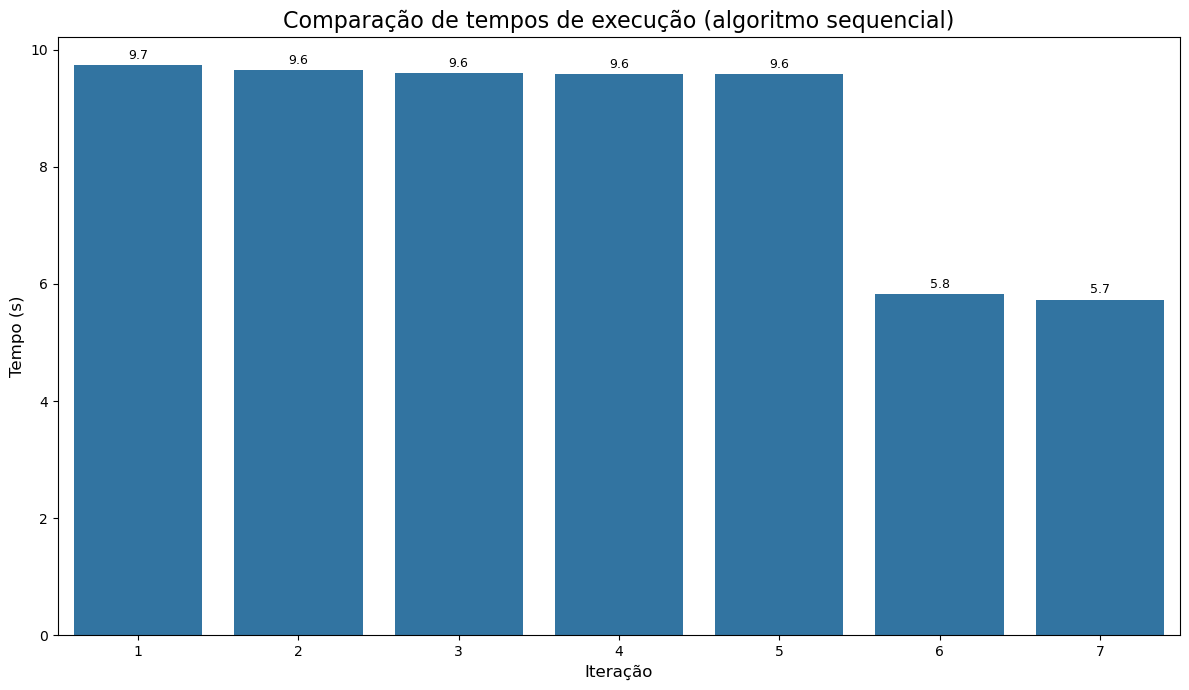

In [11]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=results_df[results_df["nome_modo"] == "sequencial"], x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo sequencial)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

### CUDA

Nesse subcapítulo serão visualizados os dados da implementação com CUDA.

In [12]:
results_df.tail(7)

,interacao,tempo,threshold,nome_modo,valor_modo,Fab
7,1,0.012,0.5,CUDA,NaN,NaN
8,2,0.012,0.5,CUDA,NaN,NaN
9,3,0.012,0.5,CUDA,NaN,NaN
10,4,0.012,0.5,CUDA,NaN,NaN
11,5,0.012,0.5,CUDA,NaN,NaN
12,6,0.012,0.5,CUDA,NaN,NaN
13,7,0.012,0.5,CUDA,NaN,NaN


##### Tempo de execução

In [13]:
print("TEMPO")
print("Média:", results_df[results_df["nome_modo"] == "CUDA"]["tempo"].mean())
print("Desvio padrão:", results_df[results_df["nome_modo"] == "CUDA"]["tempo"].std())
print("Valor mínimo:", results_df[results_df["nome_modo"] == "CUDA"]["tempo"].min())
print("Valor máximo:", results_df[results_df["nome_modo"] == "CUDA"]["tempo"].max())

TEMPO
Média: 0.011999999999999999
Desvio padrão: 1.8737155052077408e-18
Valor mínimo: 0.012
Valor máximo: 0.012


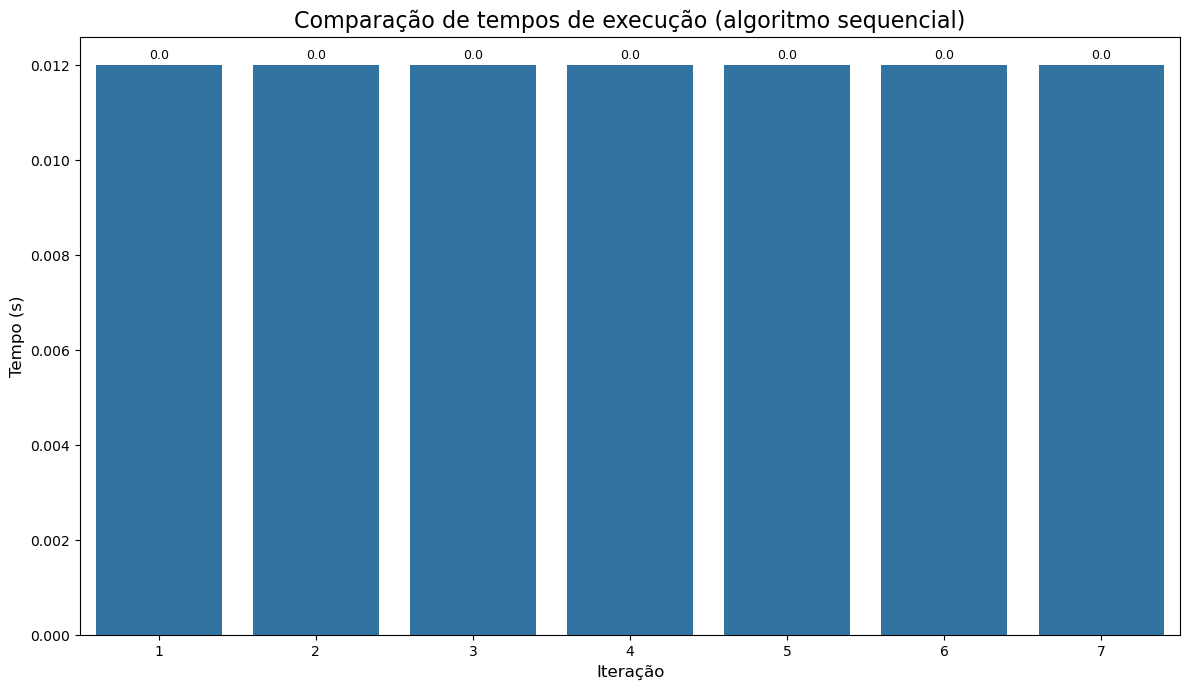

In [14]:
plt.figure(figsize=(12, 7))
axis = sns.barplot(data=results_df[results_df["nome_modo"] == "CUDA"], x="interacao", y="tempo")
plt.title("Comparação de tempos de execução (algoritmo sequencial)", fontsize=16)
plt.xlabel("Iteração", fontsize=12)
plt.ylabel("Tempo (s)", fontsize=12)

for plot in axis.patches:
    if plot.get_height() > 0:
        axis.annotate(format(plot.get_height(), ".1f"),
                      (plot.get_x() + plot.get_width() / 2.0,
                       plot.get_height()),
                      ha="center",
                      va="center",
                      xytext=(0, 7), 
                      textcoords="offset points",
                      fontsize=9)

plt.tight_layout()
plt.show()

Como, ao utilizar CUDA, não há maneiras de calcular o Fator de Balanceamento de Carga, não serão feitos os testes de cálculo de Speed-up e Eficiência.

### Teste de corretude

#### Consistência

Os testes foram realizados com 5 imagens de *label* de artérias coronárias retiradas do trabalho  [Imagecas](https://www.sciencedirect.com/science/article/abs/pii/S0895611123001052). Mais precisamente, as imagens: 120, 205, 510, 650, e 980.

#### Utilizando o terminal Linux (Bash)

Utilizando o comando `diff` com a *flag* `-q` e os hiperparâmetros `output_sequential.txt` e `output_CUDA.txt` foi feita uma comparação entre os dois aquivos de saída.
<br>
O utilitário `diff` mostra quais são as diferenças, mas com a *flag* -q (*quiet*/*brief*), ele apenas dá um resumo se os arquivos são diferentes ou não.
<br>
Nesse teste, o `diff` não mostrou saída nenhuma. Isso é uma indicação de que os arquivo são idênticos.
<br>
É possível reproduzir o resultado no terminal Linux (Bash) utilizando o trecho de código abaixo.

```sh
diff -q output_sequential.txt output_CUDA.txt
```

#### Comparação com algoritmo implementado em linguagem Python

O algoritmo de *bounding box* implementando nesse trabalho foi validado em contraste com o algoritmo Python abaixo.
```python
def get_crop(pre_label, img, label,enhance):
    x, y, z = np.where(pre_label == 1)
    img_shape = img.shape

    x_max = (x.max() + 5) if (x.max() + 5) <= img_shape[0] else img_shape[0]
    y_max = (y.max() + 5) if (y.max() + 5) <= img_shape[1] else img_shape[1]
    z_max = (z.max() + 5) if (z.max() + 5) <= img_shape[2] else img_shape[2]

    x_min = x.min() - 5 if (x.min() - 5) >= 0 else 0
    y_min = y.min() - 5 if (y.min() - 5) >= 0 else 0
    z_min = z.min() - 5 if (z.min() - 5) >= 0 else 0

    loc_max = [x_max, y_max, z_max]
    loc_min = [x_min, y_min, z_min]

    img_crop = img[loc_min[0]:loc_max[0], loc_min[1]:loc_max[1], loc_min[2]:loc_max[2]]
    label_crop = label[loc_min[0]:loc_max[0], loc_min[1]:loc_max[1], loc_min[2]:loc_max[2]]
    enhance_crop = enhance[loc_min[0]:loc_max[0], loc_min[1]:loc_max[1], loc_min[2]:loc_max[2]]
    return img_crop, label_crop, enhance_crop, loc_min, loc_max
```

Para se adequar ao problema atual, será feita a seguinte modificação no código.

```python
def get_crop(label):
    x, y, z = np.where(label == 1)
    label_shape = label.shape

    x_max = min(x.max() + 5, label_shape[0])
    y_max = min(y.max() + 5, label_shape[1])
    z_max = min(z.max() + 5, label_shape[2])

    x_min = max(x.min() - 5, 0)
    y_min = max(y.min() - 5, 0)
    z_min = max(z.min() - 5, 0)

    loc_max = [x_max, y_max, z_max]
    loc_min = [x_min, y_min, z_min]

    label_crop = label[loc_min[0]:loc_max[0], 
                       loc_min[1]:loc_max[1], 
                       loc_min[2]:loc_max[2]]

    return label_crop
```

O algoritmo acima for retirado do artigo [Imagecas](https://www.sciencedirect.com/science/article/abs/pii/S0895611123001052).
A saída do trecho acima não foi salvo em arquivo.
<br>
A implementação do teste está apresentada abaixo.

##### Execução do teste

###### Importando pacotes

In [15]:
import nibabel as nib

###### Funções

In [16]:
def get_crop(label):
    x, y, z = np.where(label == 1)
    label_shape = label.shape

    x_max = min(x.max() + 5, label_shape[0])
    y_max = min(y.max() + 5, label_shape[1])
    z_max = min(z.max() + 5, label_shape[2])

    x_min = max(x.min() - 5, 0)
    y_min = max(y.min() - 5, 0)
    z_min = max(z.min() - 5, 0)

    loc_max = [x_max, y_max, z_max]
    loc_min = [x_min, y_min, z_min]

    label_crop = label[loc_min[0]:loc_max[0], 
                       loc_min[1]:loc_max[1], 
                       loc_min[2]:loc_max[2]]

    return label_crop

def load_tensor_from_text_file(file_path: str) -> np.ndarray[float]:
    content: str

    with open(file_path, "r") as file_descriptor:
        content = file_descriptor.read()

    raw_data: str = content.replace("---- ---- ----", " ").replace("\n", " ")
    temp_tensor: nd.ndarray[float] = np.fromstring(raw_data, sep="\t")

    slices_string: str = content.strip().split("---- ---- ----")
    first_slice_lines: str = slices_string[0].strip().split("\n")

    x_axis: int = len(first_slice_lines)
    y_axis: int = len([val for val in first_slice_lines[0].split("\t") if val.strip()])
    total_elements: int = temp_tensor.size
    z_axis: int = total_elements // (x_axis * y_axis)

    if total_elements != (z_axis * x_axis * y_axis):
        print(f"Aviso: Dados desalinhados. Total: {total_elements}, Esperado: {z_axis * x_axis * y_axis}")
        temp_tensor = temp_tensor[:z_axis * x_axis * y_axis]

    tensor: np.ndarray[float] = temp_tensor.reshape((z_axis, x_axis, y_axis))

    return tensor.transpose(1, 2, 0)

###### *Bounding box* próprio

In [17]:
file_path: str = "../input3.txt"

with open(file_path, "r") as file_descriptor:
    print("Dimensões da imagem original:")
    print("- Linhas:", file_descriptor.readline().strip())
    print("- Colunas:", file_descriptor.readline().strip())
    print("- Slices:", file_descriptor.readline().strip())

Dimensões da imagem original:
- Linhas: 512
- Colunas: 512
- Slices: 275


In [18]:
file_path: str = "../output_sequential.txt"
cropped_tensor: np.ndarray = load_tensor_from_text_file(file_path)

print("Tamanho da imagem cortada:", cropped_tensor.shape)

Tamanho da imagem cortada: (314, 249, 182)


###### *Bounding box* de validação

In [19]:
image_path: str = "../images/120.label.nii.gz"
tensor: np.ndarray = nib.load(image_path).get_fdata()
cropped_tensor_validation: np.ndarray = get_crop(tensor)

print("Dimensões da imagem original:", tensor.shape)
print("Dimensões da imagem cortada:", cropped_tensor_validation.shape)

Dimensões da imagem original: (512, 512, 275)
Dimensões da imagem cortada: (313, 248, 181)


In [20]:
cropped_tensor = cropped_tensor[:313, :248, :181]

In [21]:
difference_array: np.ndarray[float] = cropped_tensor_validation - cropped_tensor

print("Maior valor da subtração:", np.max(difference_array))
print("Quantidade de valores não nulos:", np.count_nonzero(difference_array == 1.0))

Maior valor da subtração: 0.0
Quantidade de valores não nulos: 0


##### Execução do teste com o mesmo arquivo de entrada (`input3.txt`).

In [22]:
file_path: str = "../input3.txt"
tensor: np.ndarray[float] = np.loadtxt(file_path, delimiter=" ", skiprows=3, dtype=float).reshape((512, 512, 275))

print("Dimensões da imagem original:", tensor.shape)

cropped_tensor_validation: np.ndarray[float] = get_crop(tensor)

print("Dimensões da imagem cortada:", cropped_tensor_validation.shape)

Dimensões da imagem original: (512, 512, 275)
Dimensões da imagem cortada: (313, 248, 181)


In [23]:
difference_array = cropped_tensor_validation - cropped_tensor[:313, :248, :181]

print("Maior valor da subtração:", np.max(difference_array))
print("Quantidade de valores não nulos:", np.count_nonzero(difference_array == 1.0))

Maior valor da subtração: 0.0
Quantidade de valores não nulos: 0


### Melhor resultado (Tempo de execução)
A combinação que demonstrou o menor tempo de execução foi `(dynamic, 2)` com `5,485201` segundos.
<br>
Resultado da iteração 3.
<br>
O melhor tempo do algoritmo iterativo foi `5,733536` segundos.
<br>
Resultado da iteração 7.
<br>
### Pior resultado (Tempo de execução)
A combinação que demonstrou o maior tempo de execução foi `(guided, 8)` com `11,572992` segundos.
<br>
Resultado da iteração 1.
<br>
O pior tempo do algoritmo iterativo foi `9,73603` segundos.
<br>
Resultado da iteração 1.
<br>